[('aggressive_bidder', <threshold_bidder.ThresholdBidder object at 0x1066e9850>), ('passive_bidder', <threshold_bidder.ThresholdBidder object at 0x11d757e90>), ('dp_bidder1', <dp_bidder.DPBidder object at 0x1066fb7d0>), ('dp_bidder2', <dp_bidder.DPBidder object at 0x1066e9f50>)]
DP bidder1 config: {'center_frac': 0.6, 'scale_frac': 0.18, 'payment_factor': 0.6, 'bid_step': 1, 'enforce_start_price': True}
DP bidder2 config: {'center_frac': 0.5, 'scale_frac': 0.25, 'payment_factor': 0.65, 'bid_step': 1, 'enforce_start_price': True}


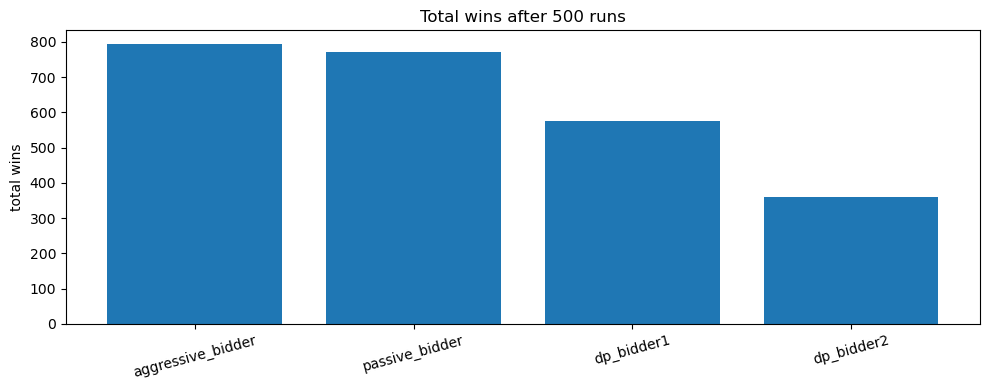

In [1]:
import io
import re
import importlib
import matplotlib.pyplot as plt
from contextlib import redirect_stdout

import heuristic_agents as ha
importlib.reload(ha)

RANDOMIZE_AGENT_ORDER = ha.RANDOMIZE_AGENT_ORDER
agent_setups = ha.build_agent_setups(ha.ITEM_VALUES, ha.STARTING_BUDGET)
print(agent_setups)
print("DP bidder1 config:", ha.DP_BIDDER1_CONFIG)
print("DP bidder2 config:", ha.DP_BIDDER2_CONFIG)


def run_auction_batch(num_runs):
    ha.PLAYER_INVOLVED = False
    ha.RANDOMIZE_ITEMS = True
    ha.RANDOMIZE_AGENT_ORDER = RANDOMIZE_AGENT_ORDER

    agent_names = [name for name, _ in ha.build_agent_setups(ha.ITEM_VALUES, ha.STARTING_BUDGET)]
    total_wins = {name: 0 for name in agent_names}

    for _ in range(num_runs):
        buffer = io.StringIO()
        with redirect_stdout(buffer):
            ha.main()

        for line in buffer.getvalue().splitlines():
            match = re.match(r"Items (.+) won: (.+)", line.strip())
            if not match:
                continue
            agent_name, payload = match.groups()
            if agent_name not in total_wins:
                continue
            if payload.strip() == "none":
                continue
            total_wins[agent_name] += len(re.findall(r"\d+", payload))

    return total_wins


num_runs = 500
total_wins = run_auction_batch(num_runs)

ordered = sorted(total_wins.items(), key=lambda x: x[1], reverse=True)
agent_names = [x[0] for x in ordered]
wins = [x[1] for x in ordered]

plt.figure(figsize=(10, 4))
plt.bar(agent_names, wins)
plt.ylabel("total wins")
plt.title(f"Total wins after {num_runs} runs")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
